In [1]:
%env XLA_PYTHON_CLIENT_PREALLOCATE=False

import os
import pickle

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from adaptive_smc.save_and_read_and_postprocess import acf


PKLs = []
PKL_titles = []
DIR = "./uncoupled_ar_rw_proposal/output_dim6_mean0_2000/"
for file in os.listdir(DIR):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(DIR + file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)

env: XLA_PYTHON_CLIENT_PREALLOCATE=False


In [2]:
list_idx_rwmh = []
list_idx_ar = []
for i in range(n):
    if 'rw' in PKLs[i]['config']['proposal']:
        list_idx_rwmh.append(i)
    else:
        list_idx_ar.append(i)

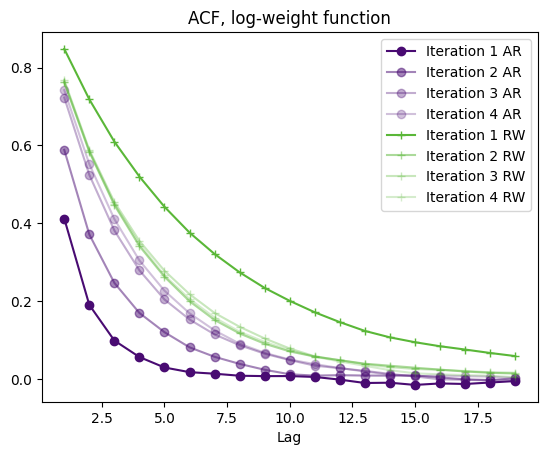

In [6]:
NUM_COLORS = 30
color_set = set()
while len(color_set) < NUM_COLORS:
    random_integers = [np.random.randint(0, 255) / 255 for _ in range(3)]
    color_set.add(tuple(random_integers))
color_set = list(color_set)

labels = ['AR', 'RW']
list_max = 100
for _idx, l in enumerate([list_idx_ar[:list_max], list_idx_rwmh[:list_max]]):
    for idx in l:
        acfs = acf(PKLs[idx]['res'][0][:,:,0, ..., :1])[..., 0, 0]
        max_temp_idx = jnp.min(jnp.argwhere(PKLs[idx]['res'][6] == 1), axis=0)[1]
        for it in range(1, max_temp_idx):
            if it % 1 == 0:
                plt.plot(np.arange(1, 20), acfs[:, it], marker='o' if _idx == 0 else '+',
                         label=f"Iteration {it} {labels[_idx]}" if it in [1,5, 10], color=color_set[_idx], alpha=1 / (it))
        plt.legend()
plt.xlabel(r"Lag $l$")
plt.ylabel("Estimated autocorrelation")
plt.title("ACF, log-weight function")
plt.savefig(DIR+"ACF.png")

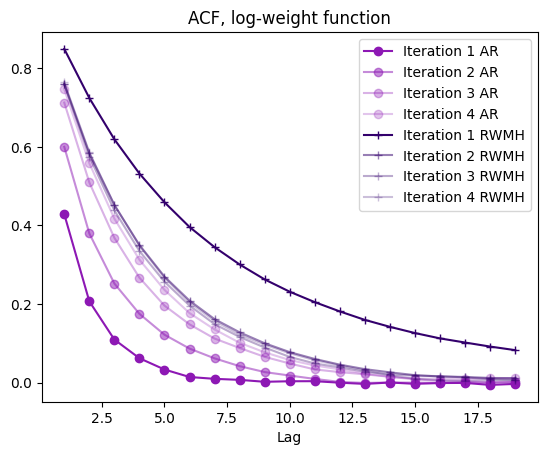

In [4]:
from adaptive_smc.problems.gaussian import create_problem

tau = jnp.sqrt(0.1)
dim = PKLs[0]['res'][0].shape[-1]
cov = jnp.eye(dim) * 1 / (1 / tau ** 2 - 1)
mean = jnp.ones(dim)

loglikelihood_fn = create_problem(dim, mean=jnp.ones(dim), scale=jnp.sqrt(1 / (1 / tau ** 2 - 1)))


def log_weight_function(dlmbda, x):
    ll = loglikelihood_fn(x)
    dlmbda = dlmbda.reshape(dlmbda.shape + (1,) * (jnp.ndim(ll) - jnp.ndim(dlmbda)))
    return dlmbda * ll


labels = ['AR', 'RWMH']

for _idx, l in enumerate([list_idx_ar, list_idx_rwmh]):
    for idx in l:
        samples = PKLs[idx]['res'][0][:,:,0]
        dlmbdas = jnp.diff(jnp.insert(PKLs[0]['res'][6], 0, 0., -1), axis=-1) # inserting 0, \lmbda_1, \lmbda_2-\lmbda1, ..., \lmbda_{T-1}-\lambda_T
        max_temp_idx = jnp.min(jnp.argwhere(PKLs[idx]['res'][6] == 1), axis=0)[1]
        log_weights = jnp.expand_dims(log_weight_function(dlmbdas, samples), -1)
        acfs = acf(log_weights)[..., 0, 0]
        for it in range(1, max_temp_idx):
            if it % 1 == 0:
                plt.plot(np.arange(1, 20), acfs[:, it], marker='o' if _idx == 0 else '+',
                         label=f"Iteration {it} {labels[_idx]}", color=color_set[_idx], alpha=1 / (it),
                         )
        plt.legend()
plt.xlabel("Lag")
plt.title("ACF, log-weight function")
plt.savefig(DIR+"ACF_lw.png")

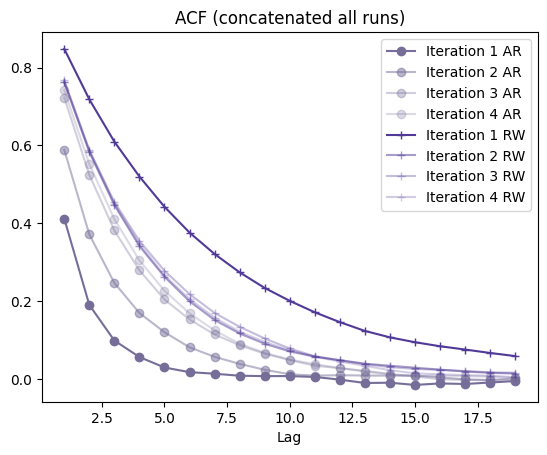

In [5]:
# Doing the same computations as previously but first concatenating each chains
NUM_COLORS = 30
color_set = set()
while len(color_set) < NUM_COLORS:
    random_integers = [np.random.randint(0, 255) / 255 for _ in range(3)]
    color_set.add(tuple(random_integers))
color_set = list(color_set)

labels = ['AR', 'RW']
list_max = 100
for _idx, l in enumerate([list_idx_ar[:list_max], list_idx_rwmh[:list_max]]):
    samples = jnp.concatenate([PKLs[idx]['res'][0][:,:,0, ..., :1] for idx in l], axis=0)
    acfs = acf(samples)[..., 0, 0]
    max_temp_idx = max([jnp.min(jnp.argwhere(PKLs[idx]['res'][6] == 1), axis=0)[1] for idx in l])
    for it in range(1, max_temp_idx):
        if it % 1 == 0:
            plt.plot(np.arange(1, 20), acfs[:, it], marker='o' if _idx == 0 else '+',
                     label=f"Iteration {it} {labels[_idx]}", color=color_set[_idx], alpha=1 / (it))
    plt.legend()
plt.xlabel("Lag")
plt.title("ACF (concatenated all runs)")
plt.savefig(DIR+"ACF.png")